<a href="https://colab.research.google.com/github/vithula30/ml_sentiment_analysis/blob/main/ML_CYS_Word_Vectorizers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



**Models Evaluated:**
| # | Model |
|---|-------|
| 1 | Bag of Words + Naive Bayes |
| 2 | Bag of Words + Logistic Regression |
| 3 | Bag of Words + SVM |
| 4 | TF-IDF + Naive Bayes |
| 5 | TF-IDF + Logistic Regression |
| 6 | TF-IDF + SVM |
| 7 | N-Gram (BoW) + Naive Bayes |
| 8 | TF-IDF + N-Gram + Naive Bayes |
| 9 | TF-IDF + N-Gram + Logistic Regression |
| 10 | TF-IDF + N-Gram + SVM |
| 11 | BiLSTM |
| 12 | RoBERTa (roberta-base) |
| 13 | Char-CNN (Deep Learning) |

**Dataset:** Playstore App Reviews (Balanced Dataset — binary classification)

In [1]:
import pandas as pd
from google.colab import files
import io

print('Please upload "playstore_balanced.csv" from your computer:')
uploaded = files.upload()

# Get the filename from the upload dictionary
file_name = list(uploaded.keys())[0]
df_playstore = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f'Successfully loaded {file_name}')
display(df_playstore.head())

Please upload "playstore_balanced.csv" from your computer:


Saving playstore_balanced.csv to playstore_balanced.csv
Successfully loaded playstore_balanced.csv


,text,rating,label
0,Videos you pay money for will stutter and not ...,1,negative
1,updates are trash. not sure what the problem i...,2,neutral
2,very slow and clunky ui. app glitches when sel...,2,neutral
3,llevo ya varios dias tratando de subir histori...,1,negative
4,This app is very useful 😄👍,5,positive


## 🔧 Step 0: Install Dependencies

In [2]:
!pip install -q transformers datasets torch scikit-learn nltk matplotlib seaborn pandas

---
# 📚 PART 1: Literature Review
## Word Vectorization in NLP

### 1.1 What is Word Vectorization?

Word vectorization (or text representation) is the process of converting raw text into numerical vectors that machine learning models can process. Since ML models operate on numbers, not strings, vectorization is a **fundamental step** in every NLP pipeline.

Good vectorization preserves semantic meaning, context, and structure of the original text.

---

### 1.2 Conventional Vectorization Methods

#### 1️⃣ Bag of Words (BoW)
- **Principle:** Represents text as an unordered collection ("bag") of words, ignoring grammar and word order.
- **How it works:** Build a vocabulary of all unique words across the corpus. Each document becomes a vector of word counts.
- **Strengths:** Simple, fast, interpretable.
- **Weaknesses:** Ignores word order and semantics; creates very sparse, high-dimensional vectors.
- **Applications:** Spam detection, basic text classification.

#### 2️⃣ TF-IDF (Term Frequency – Inverse Document Frequency)
- **Principle:** Weights words by how frequently they appear in a document (TF) relative to how common they are across all documents (IDF).
- **Formula:** `TF-IDF(t,d) = TF(t,d) %% log(N / df(t))`
- **Strengths:** Reduces weight of common words ("the", "is"); highlights discriminative terms.
- **Weaknesses:** Still ignores word order; does not capture semantic similarity.
- **Applications:** Information retrieval, document ranking, sentiment analysis.

#### 3️⃣ N-Gram Models
- **Principle:** Extends BoW by treating consecutive sequences of N words as features.
- **Example:** Bigrams (N=2) capture "not good" as a single feature, preserving some context.
- **Strengths:** Captures local word order and short phrases.
- **Weaknesses:** Vocabulary explodes with larger N; still no global semantics.
- **Applications:** Language modeling, sentiment analysis with negation handling.

---

### 1.3 Deep Learning Vectorization Methods

#### 4️⃣ BiLSTM (Bidirectional LSTM)
- **Principle:** Learns sequential context by processing text both forward and backward through an LSTM network.
- **Strengths:** Captures long-range dependencies and word order; learns representations end-to-end.
- **Weaknesses:** Slow to train; needs more data than conventional methods.

#### 5️⃣ RoBERTa (Robustly Optimized BERT Pretraining Approach)
- **Principle:** A transformer-based model pretrained on massive corpora using masked language modeling. Fine-tuned for downstream tasks.
- **Strengths:** State-of-the-art performance; captures deep semantic and contextual relationships.
- **Weaknesses:** Computationally expensive; requires GPU for reasonable training time.

#### 6️⃣ Char-CNN (Character-level CNN)
- **Principle:** Processes text as a sequence of characters rather than words, using 1D convolutional layers to extract structural features.
- **Strengths:** Robust to misspellings, typos, and out-of-vocabulary (OOV) words; smaller vocabulary size.
- **Weaknesses:** Ignores word-level semantic hierarchies; can be computationally intensive for very long documents.

---

---
# 🧪 PART 2: Experimentation

## 2.1 Imports & Global Setup

In [3]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import nltk
import re
import torch
import torch.nn as nn

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset as TorchDataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

warnings.filterwarnings('ignore')
STOP_WORDS = set(stopwords.words('english'))
STEMMER = PorterStemmer()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')

# Results store
results = []

✅ Device: cuda


## 2.2 Dataset Loading — Playstore Sentiment

In [4]:
# Assuming df_playstore is already loaded from cell d8264b48
print('Processing Playstore dataset...')

# Filter out 'neutral' labels for binary classification as the original notebook was set up for binary classification.
df_binary = df_playstore[df_playstore['label'].isin(['positive', 'negative'])].copy()

# Map labels to 0 and 1
label_mapping = {'negative': 0, 'positive': 1}
df_binary['label'] = df_binary['label'].map(label_mapping)

# Define a limit for the dataset size to control experimentation speed
# Set to None to use all available binary samples.
DATASET_SIZE_LIMIT = 10000

if DATASET_SIZE_LIMIT:
    if len(df_binary) > DATASET_SIZE_LIMIT:
        # Randomly sample from the balanced dataset to meet the size limit
        df_binary = df_binary.sample(n=DATASET_SIZE_LIMIT, random_state=42).reset_index(drop=True)
    else:
        print(f"Warning: Dataset size ({len(df_binary)}) is less than DATASET_SIZE_LIMIT ({DATASET_SIZE_LIMIT}). Using full dataset.")

# Split the dataset into training and testing
# Using a fixed random state for reproducibility and stratify to maintain label distribution
train_df, test_df = train_test_split(df_binary, test_size=0.2, random_state=42, stratify=df_binary['label'])

train_texts  = train_df['text'].tolist()
train_labels = train_df['label'].tolist()
test_texts   = test_df['text'].tolist()
test_labels  = test_df['label'].tolist()

print(f'Train samples : {len(train_texts)}')
print(f'Test  samples : {len(test_texts)}')
print(f'Label distribution (train): {Counter(train_labels)}')
print('\nSample review:')
print(train_texts[0][:300], '...')

Processing Playstore dataset...
Train samples : 8000
Test  samples : 2000
Label distribution (train): Counter({1: 4022, 0: 3978})

Sample review:
great to work with thanks for what you do. ...


## 2.3 Text Preprocessing

In [5]:
def preprocess(text):
    """Tokenization, lowercasing, HTML removal, stop-word removal, stemming."""
    text = re.sub(r'<.*?>', ' ', text)           # remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)    # remove non-alpha
    text = text.lower()
    tokens = text.split()
    tokens = [STEMMER.stem(t) for t in tokens if t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

print('Preprocessing texts...')
t0 = time.time()
train_clean = [preprocess(t) for t in train_texts]
test_clean  = [preprocess(t) for t in test_texts]
print(f'Done in {time.time()-t0:.1f}s')
print('\nSample preprocessed:')
print(train_clean[0][:300])

Preprocessing texts...
Done in 3.5s

Sample preprocessed:
great work thank


## 2.4 Evaluation Helper

In [6]:
def evaluate_and_store(name, y_true, y_pred, vec_time, train_time):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='binary')
    rec  = recall_score(y_true, y_pred, average='binary')
    f1   = f1_score(y_true, y_pred, average='binary')
    total_time = vec_time + train_time
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'Vec Time (s)': round(vec_time, 2),
        'Train Time (s)': round(train_time, 2),
        'Total Time (s)': round(total_time, 2),
    })
    print(f'\n=== {name} ===')
    print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))
    print(f'⏱  Vec: {vec_time:.2f}s | Train: {train_time:.2f}s | Total: {total_time:.2f}s')
    return acc, f1

---
## Model 1: Bag of Words + Naive Bayes

In [7]:
# Vectorization
t0 = time.time()
bow_vec = CountVectorizer(max_features=30000)
X_train_bow = bow_vec.fit_transform(train_clean)
X_test_bow  = bow_vec.transform(test_clean)
vec_time = time.time() - t0

# Training
t0 = time.time()
nb1 = MultinomialNB()
nb1.fit(X_train_bow, train_labels)
train_time = time.time() - t0

preds = nb1.predict(X_test_bow)
evaluate_and_store('Bag of Words + Naive Bayes', test_labels, preds, vec_time, train_time)


=== Bag of Words + Naive Bayes ===
              precision    recall  f1-score   support

    Negative       0.86      0.88      0.87       995
    Positive       0.88      0.86      0.87      1005

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

⏱  Vec: 0.29s | Train: 0.01s | Total: 0.30s


(0.8705, 0.8693898134140191)

## Model 2: Bag of Words + Logistic Regression

In [8]:
# X_train_bow and X_test_bow already computed
t0 = time.time()
lr1 = LogisticRegression(max_iter=1000, C=1.0)
lr1.fit(X_train_bow, train_labels)
train_time = time.time() - t0

preds = lr1.predict(X_test_bow)
evaluate_and_store('Bag of Words + Logistic Regression', test_labels, preds, 0.0, train_time)


=== Bag of Words + Logistic Regression ===
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87       995
    Positive       0.86      0.88      0.87      1005

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

⏱  Vec: 0.00s | Train: 0.29s | Total: 0.29s


(0.8695, 0.8717444717444718)

## Model 3: Bag of Words + SVM

In [9]:
# X_train_bow and X_test_bow were computed in previous cells
t0 = time.time()
svm_bow = LinearSVC(C=1.0, max_iter=2000)
svm_bow.fit(X_train_bow, train_labels)
train_time = time.time() - t0

# Prediction and evaluation
preds_bow_svm = svm_bow.predict(X_test_bow)
evaluate_and_store('Bag of Words + SVM', test_labels, preds_bow_svm, 0.0, train_time)


=== Bag of Words + SVM ===
              precision    recall  f1-score   support

    Negative       0.86      0.84      0.85       995
    Positive       0.85      0.86      0.86      1005

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

⏱  Vec: 0.00s | Train: 0.41s | Total: 0.41s


(0.854, 0.8561576354679803)

## Model 3: TF-IDF + Naive Bayes

In [10]:
t0 = time.time()
tfidf_vec = TfidfVectorizer(max_features=30000, sublinear_tf=True)
X_train_tfidf = tfidf_vec.fit_transform(train_clean)
X_test_tfidf  = tfidf_vec.transform(test_clean)
vec_time = time.time() - t0

t0 = time.time()
nb2 = MultinomialNB()
nb2.fit(X_train_tfidf, train_labels)
train_time = time.time() - t0

preds = nb2.predict(X_test_tfidf)
evaluate_and_store('TF-IDF + Naive Bayes', test_labels, preds, vec_time, train_time)


=== TF-IDF + Naive Bayes ===
              precision    recall  f1-score   support

    Negative       0.84      0.90      0.87       995
    Positive       0.90      0.83      0.86      1005

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

⏱  Vec: 0.30s | Train: 0.01s | Total: 0.30s


(0.8685, 0.8643630737493554)

## Model 4: TF-IDF + Logistic Regression

In [11]:
t0 = time.time()
lr2 = LogisticRegression(max_iter=1000, C=1.0)
lr2.fit(X_train_tfidf, train_labels)
train_time = time.time() - t0

preds = lr2.predict(X_test_tfidf)
evaluate_and_store('TF-IDF + Logistic Regression', test_labels, preds, 0.0, train_time)


=== TF-IDF + Logistic Regression ===
              precision    recall  f1-score   support

    Negative       0.86      0.90      0.88       995
    Positive       0.90      0.85      0.88      1005

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

⏱  Vec: 0.00s | Train: 0.33s | Total: 0.33s


(0.879, 0.8765306122448979)

## Model 5: TF-IDF + SVM

In [12]:
t0 = time.time()
svm = LinearSVC(C=1.0, max_iter=2000)
svm.fit(X_train_tfidf, train_labels)
train_time = time.time() - t0

preds = svm.predict(X_test_tfidf)
evaluate_and_store('TF-IDF + SVM', test_labels, preds, 0.0, train_time)


=== TF-IDF + SVM ===
              precision    recall  f1-score   support

    Negative       0.85      0.88      0.87       995
    Positive       0.88      0.85      0.86      1005

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

⏱  Vec: 0.00s | Train: 0.06s | Total: 0.06s


(0.8645, 0.8627848101265823)

## Model 6: N-Gram (BoW) + Naive Bayes

In [13]:
t0 = time.time()
ngram_bow_vec = CountVectorizer(ngram_range=(1, 2), max_features=50000)
X_train_ngram_bow = ngram_bow_vec.fit_transform(train_clean)
X_test_ngram_bow  = ngram_bow_vec.transform(test_clean)
vec_time = time.time() - t0

t0 = time.time()
nb3 = MultinomialNB()
nb3.fit(X_train_ngram_bow, train_labels)
train_time = time.time() - t0

preds = nb3.predict(X_test_ngram_bow)
evaluate_and_store('N-Gram (BoW) + Naive Bayes', test_labels, preds, vec_time, train_time)


=== N-Gram (BoW) + Naive Bayes ===
              precision    recall  f1-score   support

    Negative       0.83      0.91      0.87       995
    Positive       0.91      0.82      0.86      1005

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

⏱  Vec: 0.99s | Train: 0.02s | Total: 1.01s


(0.8665, 0.8605744125326371)

## Model 7: TF-IDF + N-Gram + Naive Bayes

In [14]:
t0 = time.time()
tfidf_ngram_vec = TfidfVectorizer(ngram_range=(1, 2), max_features=50000, sublinear_tf=True)
X_train_tng = tfidf_ngram_vec.fit_transform(train_clean)
X_test_tng  = tfidf_ngram_vec.transform(test_clean)
vec_time = time.time() - t0

t0 = time.time()
nb4 = MultinomialNB()
nb4.fit(X_train_tng, train_labels)
train_time = time.time() - t0

preds = nb4.predict(X_test_tng)
evaluate_and_store('TF-IDF + N-Gram + Naive Bayes', test_labels, preds, vec_time, train_time)


=== TF-IDF + N-Gram + Naive Bayes ===
              precision    recall  f1-score   support

    Negative       0.84      0.92      0.88       995
    Positive       0.91      0.82      0.87      1005

    accuracy                           0.87      2000
   macro avg       0.88      0.87      0.87      2000
weighted avg       0.88      0.87      0.87      2000

⏱  Vec: 1.05s | Train: 0.01s | Total: 1.06s


(0.8715, 0.8655154369440083)

## Model 8: TF-IDF + N-Gram + Logistic Regression

In [15]:
t0 = time.time()
lr3 = LogisticRegression(max_iter=1000, C=1.0)
lr3.fit(X_train_tng, train_labels)
train_time = time.time() - t0

preds = lr3.predict(X_test_tng)
evaluate_and_store('TF-IDF + N-Gram + Logistic Regression', test_labels, preds, 0.0, train_time)


=== TF-IDF + N-Gram + Logistic Regression ===
              precision    recall  f1-score   support

    Negative       0.85      0.91      0.88       995
    Positive       0.91      0.84      0.87      1005

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

⏱  Vec: 0.00s | Train: 2.47s | Total: 2.47s


(0.8775, 0.8736462093862816)

## Model 9: TF-IDF + N-Gram + SVM

In [16]:
# X_train_tng and X_test_tng were computed in Model 7/8
t0 = time.time()
svm_ngram = LinearSVC(C=1.0, max_iter=2000)
svm_ngram.fit(X_train_tng, train_labels)
train_time = time.time() - t0

# Prediction and evaluation
preds_ngram_svm = svm_ngram.predict(X_test_tng)
evaluate_and_store('TF-IDF + N-Gram + SVM', test_labels, preds_ngram_svm, 0.0, train_time)


=== TF-IDF + N-Gram + SVM ===
              precision    recall  f1-score   support

    Negative       0.86      0.90      0.88       995
    Positive       0.90      0.86      0.88      1005

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

⏱  Vec: 0.00s | Train: 0.12s | Total: 0.12s


(0.881, 0.8786952089704383)

---
## Model 9: BiLSTM

In [17]:
# ---- Vocabulary ----
MAX_VOCAB  = 20000
MAX_LEN    = 200
EMBED_DIM  = 64
HIDDEN_DIM = 128
BATCH_SIZE = 64
EPOCHS_LSTM = 5

all_words = Counter()
for t in train_clean:
    all_words.update(t.split())

vocab = ['<PAD>', '<UNK>'] + [w for w, _ in all_words.most_common(MAX_VOCAB - 2)]
w2i = {w: i for i, w in enumerate(vocab)}

def encode(text, w2i, max_len):
    ids = [w2i.get(w, 1) for w in text.split()][:max_len]
    return torch.tensor(ids, dtype=torch.long)

class SentimentDataset(TorchDataset):
    def __init__(self, texts, labels):
        self.data = [(encode(t, w2i, MAX_LEN), torch.tensor(l, dtype=torch.long))
                     for t, l in zip(texts, labels)]
    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

def collate_fn(batch):
    seqs, labels = zip(*batch)
    seqs_padded = pad_sequence(seqs, batch_first=True, padding_value=0)
    return seqs_padded, torch.stack(labels)

train_ds = SentimentDataset(train_clean, train_labels)
test_ds  = SentimentDataset(test_clean, test_labels)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
print(f'Vocab size: {len(vocab)}')

Vocab size: 7338


In [18]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, batch_first=True,
                                 bidirectional=True, num_layers=2, dropout=0.3)
        self.dropout   = nn.Dropout(0.4)
        self.fc        = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, (hn, _) = self.lstm(emb)
        # Concatenate final forward and backward hidden states
        h = torch.cat([hn[-2], hn[-1]], dim=1)
        return self.fc(self.dropout(h))

model_lstm = BiLSTMClassifier(len(vocab), EMBED_DIM, HIDDEN_DIM).to(DEVICE)
optimizer  = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)
criterion  = nn.CrossEntropyLoss()
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=1)

print(model_lstm)
total_params = sum(p.numel() for p in model_lstm.parameters())
print(f'\nTotal parameters: {total_params:,}')

BiLSTMClassifier(
  (embedding): Embedding(7338, 64, padding_idx=0)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)

Total parameters: 1,064,066


In [19]:
train_time_lstm_start = time.time()

for epoch in range(EPOCHS_LSTM):
    model_lstm.train()
    total_loss, correct = 0, 0
    for seqs, labels in train_dl:
        seqs, labels = seqs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model_lstm(seqs)
        loss = criterion(out, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_lstm.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        correct += (out.argmax(1) == labels).sum().item()
    train_acc = correct / len(train_ds)
    scheduler.step(total_loss)
    print(f'Epoch {epoch+1}/{EPOCHS_LSTM} | Loss: {total_loss:.3f} | Train Acc: {train_acc:.4f}')

lstm_train_time = time.time() - train_time_lstm_start

# Evaluation
model_lstm.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for seqs, labels in test_dl:
        seqs = seqs.to(DEVICE)
        out = model_lstm(seqs)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_true.extend(labels.numpy())

evaluate_and_store('BiLSTM', all_true, all_preds, 0.0, lstm_train_time)

Epoch 1/5 | Loss: 68.694 | Train Acc: 0.7090
Epoch 2/5 | Loss: 53.177 | Train Acc: 0.8030
Epoch 3/5 | Loss: 47.214 | Train Acc: 0.8275
Epoch 4/5 | Loss: 43.935 | Train Acc: 0.8413
Epoch 5/5 | Loss: 41.891 | Train Acc: 0.8519

=== BiLSTM ===
              precision    recall  f1-score   support

    Negative       0.87      0.85      0.86       995
    Positive       0.86      0.87      0.86      1005

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

⏱  Vec: 0.00s | Train: 7.95s | Total: 7.95s


(0.8625, 0.8641975308641975)

---
## Model 10: RoBERTa (roberta-base)

In [20]:
MODEL_NAME = 'roberta-base'
ROBERTA_EPOCHS = 2
ROBERTA_BATCH  = 16
MAX_LEN_ROB    = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class IMDbDatasetRoBERTa(TorchDataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True,
            max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.encodings.items()}
        item['labels'] = self.labels[i]
        return item

# Use raw (not stemmed) text for RoBERTa — transformers handle their own tokenization
rob_train_ds = IMDbDatasetRoBERTa(train_texts, train_labels, tokenizer, MAX_LEN_ROB)
rob_test_ds  = IMDbDatasetRoBERTa(test_texts,  test_labels,  tokenizer, MAX_LEN_ROB)
print('RoBERTa datasets ready.')

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

RoBERTa datasets ready.


In [21]:
model_roberta = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

training_args = TrainingArguments(
    output_dir='./roberta_output',
    num_train_epochs=ROBERTA_EPOCHS,
    per_device_train_batch_size=ROBERTA_BATCH,
    per_device_eval_batch_size=ROBERTA_BATCH,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='no',
    load_best_model_at_end=False,
    fp16=torch.cuda.is_available(),
    report_to='none',
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds)
    }

trainer = Trainer(
    model=model_roberta,
    args=training_args,
    train_dataset=rob_train_ds,
    eval_dataset=rob_test_ds,
    compute_metrics=compute_metrics,
)

t0 = time.time()
trainer.train()
rob_train_time = time.time() - t0

# Predictions
preds_output = trainer.predict(rob_test_ds)
rob_preds = np.argmax(preds_output.predictions, axis=-1)
evaluate_and_store('RoBERTa (roberta-base)', test_labels, rob_preds, 0.0, rob_train_time)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.316005,0.311830,0.890000,0.893514
2,0.227708,0.309590,0.908000,0.908367



=== RoBERTa (roberta-base) ===
              precision    recall  f1-score   support

    Negative       0.91      0.91      0.91       995
    Positive       0.91      0.91      0.91      1005

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000

⏱  Vec: 0.00s | Train: 144.44s | Total: 144.44s


(0.908, 0.9083665338645418)

## Model 13: Character-level CNN (Deep Learning)

In [22]:
import torch.nn.functional as F

# Define character-level parameters
CHARS = "abcdefghijklmnopqrstuvwxyz0123456789 -,;.!?:'\"/\\|_@#$%^&*~`+-=<>()[]{}"
char_dict = {char: i + 1 for i, char in enumerate(CHARS)}
MAX_LEN_CHAR = 256

def encode_char(text, max_len):
    text = text.lower()
    encoded = [char_dict.get(c, 0) for c in text][:max_len]
    padded = encoded + [0] * (max_len - len(encoded))
    return torch.tensor(padded, dtype=torch.long)

class CharDataset(TorchDataset):
    def __init__(self, texts, labels):
        self.data = [(encode_char(t, MAX_LEN_CHAR), torch.tensor(l, dtype=torch.long)) for t, l in zip(texts, labels)]
    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

char_train_ds = CharDataset(train_texts, train_labels)
char_test_ds = CharDataset(test_texts, test_labels)
char_train_dl = DataLoader(char_train_ds, batch_size=64, shuffle=True)
char_test_dl = DataLoader(char_test_ds, batch_size=64, shuffle=False)

In [23]:
class CharCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim)
        self.conv1 = nn.Conv1d(embed_dim, 128, kernel_size=7)
        self.conv2 = nn.Conv1d(128, 128, kernel_size=3)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.embedding(x).transpose(1, 2)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(self.dropout(x))

model_char = CharCNN(len(char_dict), 64).to(DEVICE)
optimizer = torch.optim.Adam(model_char.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

t0 = time.time()
for epoch in range(5):
    model_char.train()
    for batch_x, batch_y in char_train_dl:
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
        optimizer.zero_grad()
        out = model_char(batch_x)
        loss = criterion(out, batch_y)
        loss.backward()
        optimizer.step()
char_train_time = time.time() - t0

model_char.eval()
char_preds = []
with torch.no_grad():
    for bx, _ in char_test_dl:
        out = model_char(bx.to(DEVICE))
        char_preds.extend(out.argmax(1).cpu().numpy())

evaluate_and_store('Char-CNN', test_labels, char_preds, 0.0, char_train_time)


=== Char-CNN ===
              precision    recall  f1-score   support

    Negative       0.88      0.85      0.86       995
    Positive       0.85      0.89      0.87      1005

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

⏱  Vec: 0.00s | Train: 3.59s | Total: 3.59s


(0.8665, 0.8698196001950268)

---
# 📊 PART 3: Analysis & Comparison

## 3.1 Results Summary Table

In [24]:
df = pd.DataFrame(results)
df = df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
df.index += 1

# Style the table
styled = df.style.background_gradient(subset=['Accuracy','F1-Score'], cmap='YlGn') \
                 .background_gradient(subset=['Total Time (s)'], cmap='YlOrRd') \
                 .format(precision=4)
display(styled)

,Model,Accuracy,Precision,Recall,F1-Score,Vec Time (s),Train Time (s),Total Time (s)
1,RoBERTa (roberta-base),0.9080,0.9093,0.9075,0.9084,0.0000,144.4400,144.4400
2,TF-IDF + N-Gram + SVM,0.8810,0.9007,0.8577,0.8787,0.0000,0.1200,0.1200
3,TF-IDF + Logistic Regression,0.8790,0.8995,0.8547,0.8765,0.0000,0.3300,0.3300
4,TF-IDF + N-Gram + Logistic Regression,0.8775,0.9069,0.8428,0.8736,0.0000,2.4700,2.4700
5,Bag of Words + Logistic Regression,0.8695,0.8612,0.8826,0.8717,0.0000,0.2900,0.2900
6,Char-CNN,0.8665,0.8528,0.8876,0.8698,0.0000,3.5900,3.5900
7,Bag of Words + Naive Bayes,0.8705,0.8814,0.8577,0.8694,0.2900,0.0100,0.3000
8,TF-IDF + N-Gram + Naive Bayes,0.8715,0.9128,0.8229,0.8655,1.0500,0.0100,1.0600
9,TF-IDF + Naive Bayes,0.8685,0.8972,0.8338,0.8644,0.3000,0.0100,0.3000
10,BiLSTM,0.8625,0.8578,0.8706,0.8642,0.0000,7.9500,7.9500


## 3.2 Performance Comparison Charts

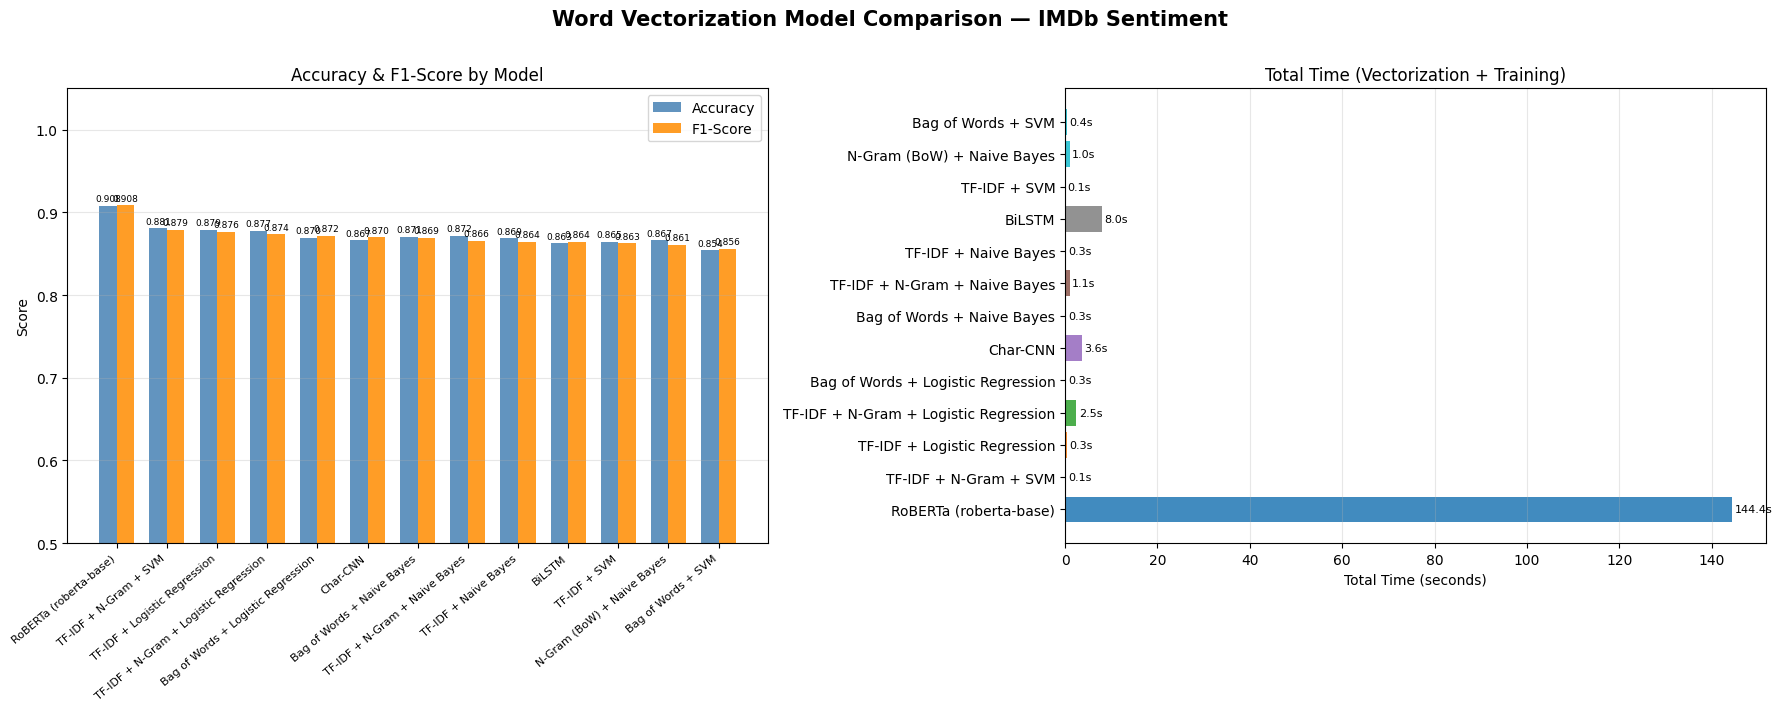

Chart saved as comparison_chart.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Word Vectorization Model Comparison — IMDb Sentiment', fontsize=15, fontweight='bold', y=1.01)

models_ordered = df['Model'].tolist()
colors = plt.cm.tab10(np.linspace(0, 1, len(models_ordered)))

# --- Chart 1: Accuracy & F1 ---
ax1 = axes[0]
x = np.arange(len(models_ordered))
w = 0.35
bars1 = ax1.bar(x - w/2, df['Accuracy'], w, label='Accuracy', color='steelblue', alpha=0.85)
bars2 = ax1.bar(x + w/2, df['F1-Score'], w, label='F1-Score',  color='darkorange', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(models_ordered, rotation=40, ha='right', fontsize=8)
ax1.set_ylim(0.5, 1.05)
ax1.set_ylabel('Score')
ax1.set_title('Accuracy & F1-Score by Model')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
for bar in bars1: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=6.5)
for bar in bars2: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=6.5)

# --- Chart 2: Total Training Time ---
ax2 = axes[1]
bars3 = ax2.barh(models_ordered, df['Total Time (s)'], color=colors, alpha=0.85)
ax2.set_xlabel('Total Time (seconds)')
ax2.set_title('Total Time (Vectorization + Training)')
ax2.grid(axis='x', alpha=0.3)
for bar in bars3:
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.1f}s', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as comparison_chart.png')

## 3.3 Multi-Metric Radar / Heatmap

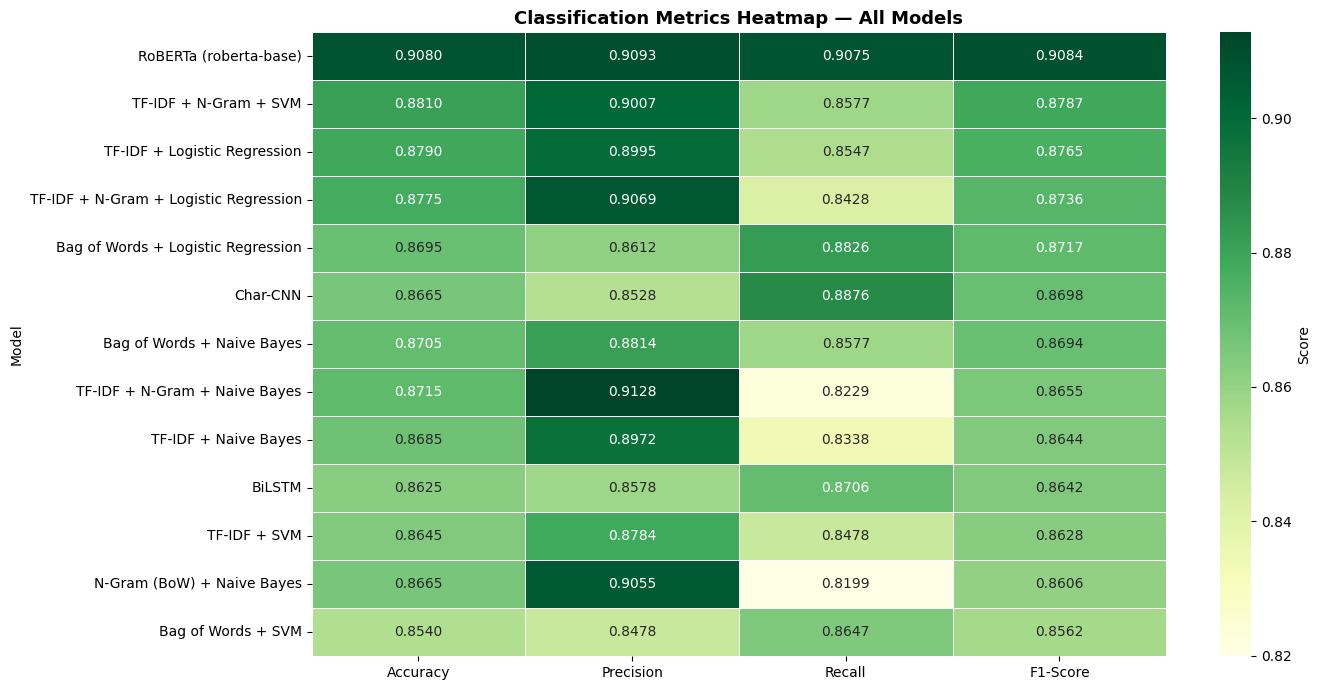

In [26]:
fig, ax = plt.subplots(figsize=(14, 7))
heat_data = df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
sns.heatmap(heat_data, annot=True, fmt='.4f', cmap='YlGn', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Score'})
ax.set_title('Classification Metrics Heatmap — All Models', fontsize=13, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.4 Confusion Matrices (All Models)

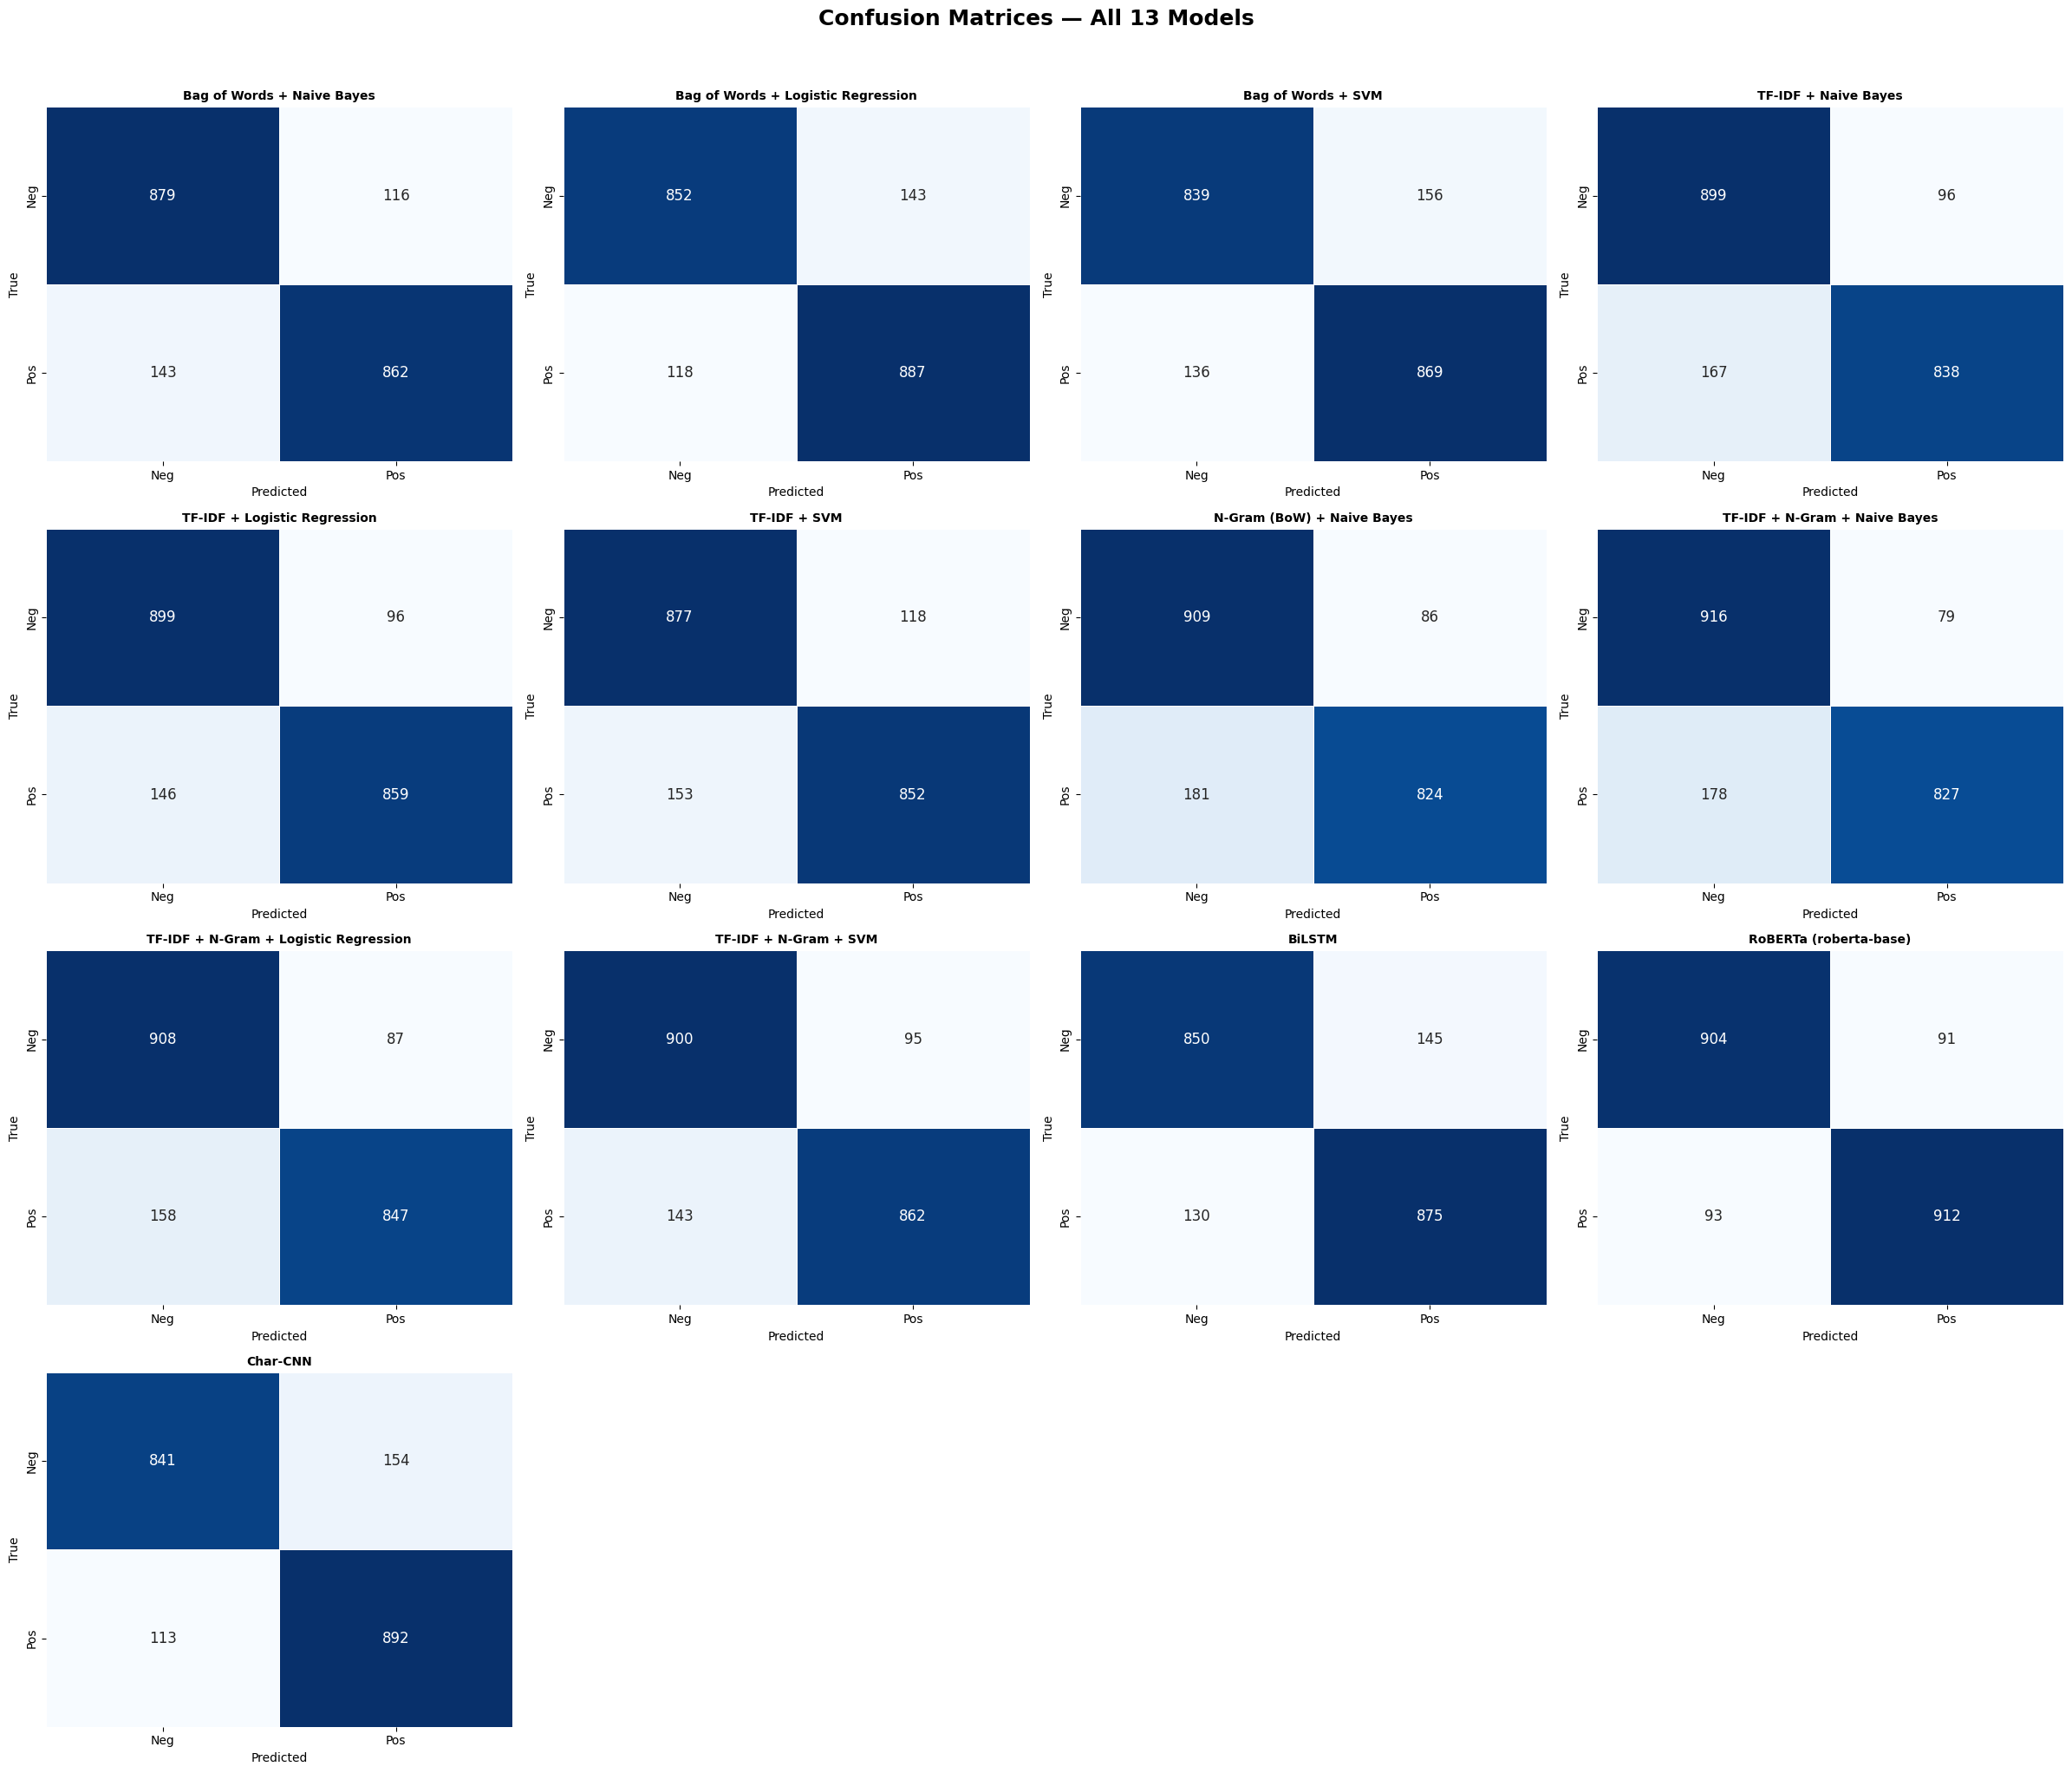

In [27]:
# Re-collect predictions for all 13 models
all_model_preds = {}

all_model_preds['Bag of Words + Naive Bayes'] = nb1.predict(X_test_bow)
all_model_preds['Bag of Words + Logistic Regression'] = lr1.predict(X_test_bow)
all_model_preds['Bag of Words + SVM'] = svm_bow.predict(X_test_bow)
all_model_preds['TF-IDF + Naive Bayes'] = nb2.predict(X_test_tfidf)
all_model_preds['TF-IDF + Logistic Regression'] = lr2.predict(X_test_tfidf)
all_model_preds['TF-IDF + SVM'] = svm.predict(X_test_tfidf)
all_model_preds['N-Gram (BoW) + Naive Bayes'] = nb3.predict(X_test_ngram_bow)
all_model_preds['TF-IDF + N-Gram + Naive Bayes'] = nb4.predict(X_test_tng)
all_model_preds['TF-IDF + N-Gram + Logistic Regression'] = lr3.predict(X_test_tng)
all_model_preds['TF-IDF + N-Gram + SVM'] = svm_ngram.predict(X_test_tng)
all_model_preds['BiLSTM'] = np.array(all_preds)
all_model_preds['RoBERTa (roberta-base)'] = rob_preds
all_model_preds['Char-CNN'] = np.array(char_preds)

# Plotting with adjusted grid (4 rows x 4 columns to fit 13 models)
fig, axes = plt.subplots(4, 4, figsize=(24, 20))
axes = axes.flatten()

for idx, (name, preds_cm) in enumerate(all_model_preds.items()):
    cm = confusion_matrix(test_labels, preds_cm)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'],
                cbar=False, linewidths=0.5, annot_kws={'size': 12})
    axes[idx].set_title(name, fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

# Hide unused subplots
for i in range(len(all_model_preds), len(axes)):
    axes[i].axis('off')

plt.suptitle('Confusion Matrices — All 13 Models', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.5 Performance vs. Time Trade-off Scatter

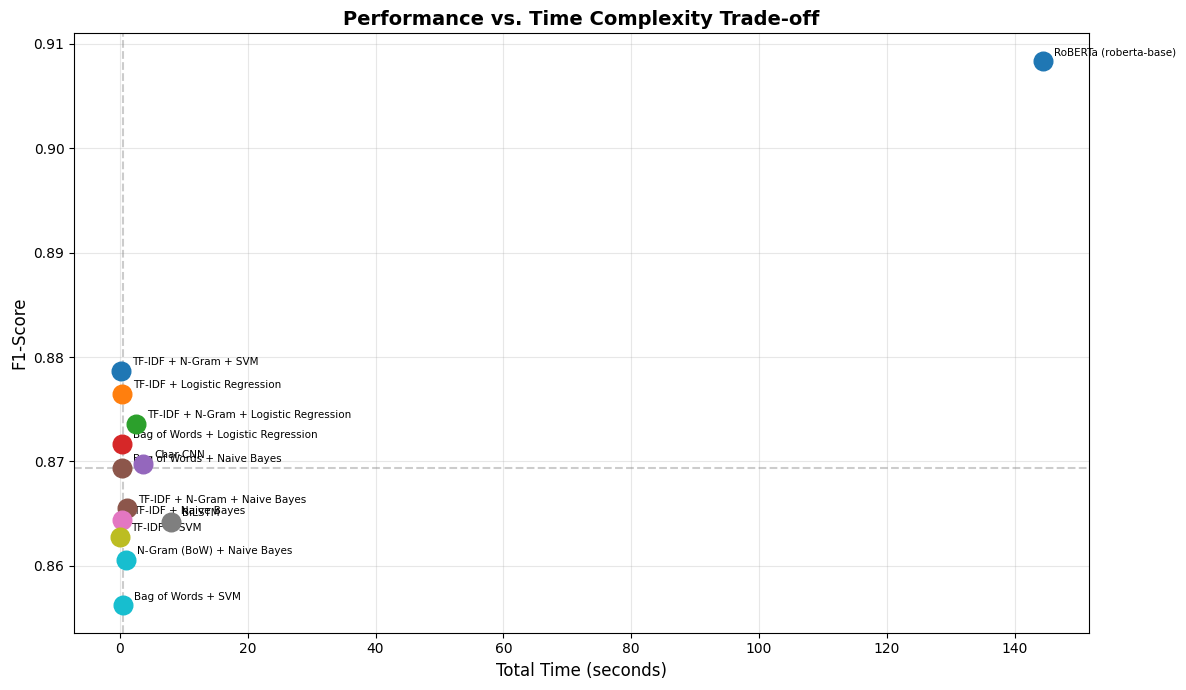

In [28]:
fig, ax = plt.subplots(figsize=(12, 7))
scatter_colors = plt.cm.tab10(np.linspace(0, 1, len(df)))

for i, row in df.iterrows():
    ax.scatter(row['Total Time (s)'], row['F1-Score'], s=180,
               color=scatter_colors[i-1], zorder=5)
    ax.annotate(row['Model'], (row['Total Time (s)'], row['F1-Score']),
                textcoords='offset points', xytext=(8, 4), fontsize=7.5)

ax.set_xlabel('Total Time (seconds)', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Performance vs. Time Complexity Trade-off', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

# Quadrant annotations
ax.axhline(df['F1-Score'].median(), color='gray', linestyle='--', alpha=0.4)
ax.axvline(df['Total Time (s)'].median(), color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('tradeoff_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3.6 Discussion: Trade-offs Analysis

### Deep Learning Methods

**BiLSTM:**
- Learns word order and long-range dependencies end-to-end.
- Slow training, needs more data.

**RoBERTa:**
- Best performance; pretrained on massive data.
- Computationally expensive.

**Char-CNN:**
- Works at the character level, making it robust to typos and slang (OOV issues).
- Faster than BiLSTM but requires careful architecture design for complex text.

# ✅ PART 4: Final Summary

In [29]:
print('=' * 65)
print('FINAL RESULTS SUMMARY')
print('=' * 65)
print(df[['Model','Accuracy','F1-Score','Total Time (s)']].to_string(index=True))
print('=' * 65)
best = df.iloc[0]
fastest = df.sort_values('Total Time (s)').iloc[0]
print(f"\n🏆 Best F1     : {best['Model']} → {best['F1-Score']:.4f}")
print(f"⚡ Fastest     : {fastest['Model']} → {fastest['Total Time (s)']:.2f}s")
print('\nAll plots saved: comparison_chart.png, metrics_heatmap.png,')
print('                 confusion_matrices.png, tradeoff_scatter.png')

FINAL RESULTS SUMMARY
                                    Model  Accuracy  F1-Score  Total Time (s)
1                  RoBERTa (roberta-base)    0.9080    0.9084          144.44
2                   TF-IDF + N-Gram + SVM    0.8810    0.8787            0.12
3            TF-IDF + Logistic Regression    0.8790    0.8765            0.33
4   TF-IDF + N-Gram + Logistic Regression    0.8775    0.8736            2.47
5      Bag of Words + Logistic Regression    0.8695    0.8717            0.29
6                                Char-CNN    0.8665    0.8698            3.59
7              Bag of Words + Naive Bayes    0.8705    0.8694            0.30
8           TF-IDF + N-Gram + Naive Bayes    0.8715    0.8655            1.06
9                    TF-IDF + Naive Bayes    0.8685    0.8644            0.30
10                                 BiLSTM    0.8625    0.8642            7.95
11                           TF-IDF + SVM    0.8645    0.8628            0.06
12             N-Gram (BoW) + Naive Bayes 